# Model Evaluation and Selection

            ## 1. Learning objectives

            - Calculate regression and classification metrics
- Use train/validation/test sets and cross-validation
- Diagnose imbalance, leakage, underfitting, overfitting, bias, and variance

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Estimate how a model will behave on unseen data and choose among candidates without contaminating the final test.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Evaluation is an experiment: control the split, compare against a baseline, quantify variability, and inspect error types.

## 6. Mathematical foundation

            $$Precision=\frac{TP}{TP+FP},\quad Recall=\frac{TP}{TP+FN},\quad F1=2\frac{Precision\cdot Recall}{Precision+Recall}.$$

            **Every symbol:**

            - $TP$ counts found positives.
- $FP$ counts false alarms.
- $FN$ counts missed positives.
- $Precision$ measures positive-prediction reliability.
- $Recall$ measures positive coverage.
- $F1$ is their harmonic mean.

            **Why the equation is needed:** On imbalanced data, accuracy can be high while the minority class is completely missed.

            **Small numerical example:** With TP=8, FP=2, FN=4, precision=.8, recall=.667, and F1=.727.

            **Connection to Python:** The scratch function counts Boolean combinations and applies each fraction with safe zero division.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

We compute the confusion counts, accuracy, precision, recall, and F1 directly before using scikit-learn displays.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def confusion_counts(y_true,y_pred):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred)
    return {
        "TP":int(np.sum((y_true==1)&(y_pred==1))),
        "TN":int(np.sum((y_true==0)&(y_pred==0))),
        "FP":int(np.sum((y_true==0)&(y_pred==1))),
        "FN":int(np.sum((y_true==1)&(y_pred==0))),
    }

def classification_metrics_scratch(y_true,y_pred):
    counts=confusion_counts(y_true,y_pred); tp,tn,fp,fn=[counts[key] for key in ["TP","TN","FP","FN"]]
    accuracy=(tp+tn)/(tp+tn+fp+fn); precision=tp/(tp+fp) if tp+fp else 0; recall=tp/(tp+fn) if tp+fn else 0
    f1=2*precision*recall/(precision+recall) if precision+recall else 0
    return counts|{"accuracy":accuracy,"precision":precision,"recall":recall,"F1":f1}

display(pd.Series(classification_metrics_scratch([1,1,0,0],[1,0,1,0])))

TP           1.0
TN           1.0
FP           1.0
FN           1.0
accuracy     0.5
precision    0.5
recall       0.5
F1           0.5
dtype: float64

## 10. Implementation using a standard library

Pipelines prevent leakage; stratified cross-validation estimates variability; ROC and precision-recall displays study thresholds.

## 11. Dataset loading and exploration

A generated 90/10 imbalanced binary dataset makes misleading accuracy behavior visible.

## 12. Data preprocessing

Scaling lives inside a Pipeline, so every cross-validation fold fits its own scaler only on that fold's training rows.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

,TP,TN,FP,FN,accuracy,precision,recall,F1
Majority baseline,0,161,0,19,0.894,0.000,0.000,0.000
Balanced logistic,12,107,54,7,0.661,0.182,0.632,0.282


ROC-AUC: 0.735 Average precision: 0.367
5-fold ROC-AUC mean/std: 0.707 0.031


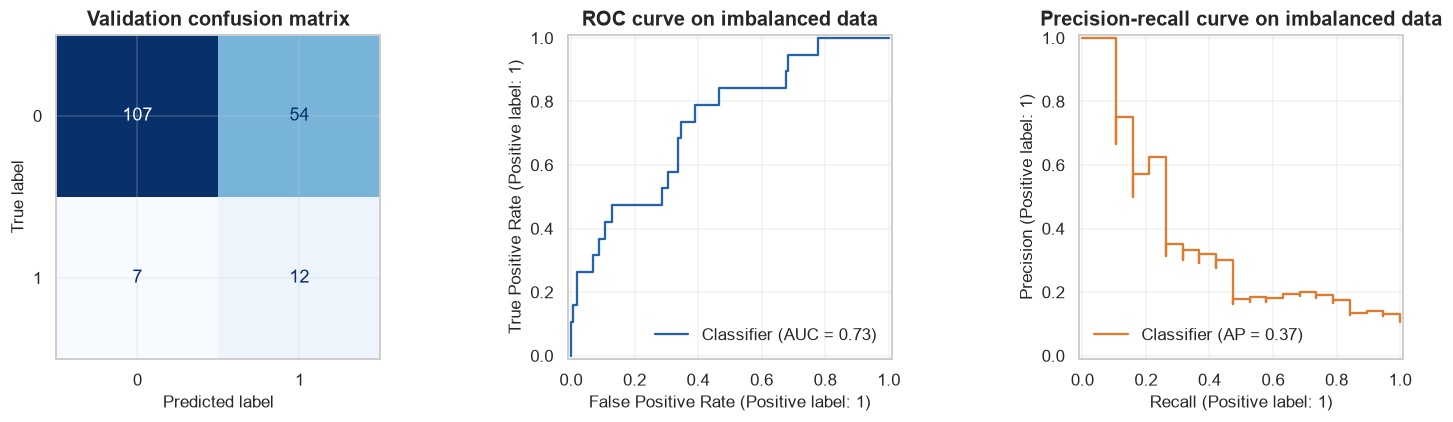

In [3]:
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,PrecisionRecallDisplay,RocCurveDisplay,average_precision_score,roc_auc_score
from sklearn.model_selection import StratifiedKFold,cross_validate,learning_curve,train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X,y=make_classification(n_samples=900,n_features=10,n_informative=5,weights=[.9,.1],class_sep=1.0,random_state=RANDOM_SEED)
X_development,X_test,y_development,y_test=train_test_split(X,y,test_size=.2,stratify=y,random_state=RANDOM_SEED)
X_train,X_validation,y_train,y_validation=train_test_split(X_development,y_development,test_size=.25,stratify=y_development,random_state=RANDOM_SEED)
baseline=DummyClassifier(strategy="most_frequent").fit(X_train,y_train)
model=make_pipeline(StandardScaler(),LogisticRegression(class_weight="balanced",max_iter=2000,random_state=RANDOM_SEED)).fit(X_train,y_train)
prediction=model.predict(X_validation); probability=model.predict_proba(X_validation)[:,1]
display(pd.DataFrame([classification_metrics_scratch(y_validation,baseline.predict(X_validation)),classification_metrics_scratch(y_validation,prediction)],index=["Majority baseline","Balanced logistic"]).round(3))
print("ROC-AUC:",round(roc_auc_score(y_validation,probability),3),"Average precision:",round(average_precision_score(y_validation,probability),3))
cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_SEED)
cv_results=cross_validate(model,X_development,y_development,cv=cv,scoring=["roc_auc","average_precision"])
print("5-fold ROC-AUC mean/std:",round(cv_results["test_roc_auc"].mean(),3),round(cv_results["test_roc_auc"].std(),3))
figure,axes=plt.subplots(1,3,figsize=(14,4))
ConfusionMatrixDisplay.from_predictions(y_validation,prediction,cmap="Blues",colorbar=False,ax=axes[0]); axes[0].set_title("Validation confusion matrix")
RocCurveDisplay.from_predictions(y_validation,probability,ax=axes[1],curve_kwargs={"color":COURSE_COLORS["blue"]}); axes[1].set_title("ROC curve on imbalanced data")
PrecisionRecallDisplay.from_predictions(y_validation,probability,ax=axes[2],curve_kwargs={"color":COURSE_COLORS["orange"]}); axes[2].set_title("Precision-recall curve on imbalanced data")
figure.tight_layout(); plt.show()

**How to interpret the result:** The majority baseline can have high accuracy yet zero minority recall. Precision-recall is especially informative when positives are rare.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

A learning curve varies training-set size. A persistent train-validation gap suggests variance; similarly low curves suggest bias.

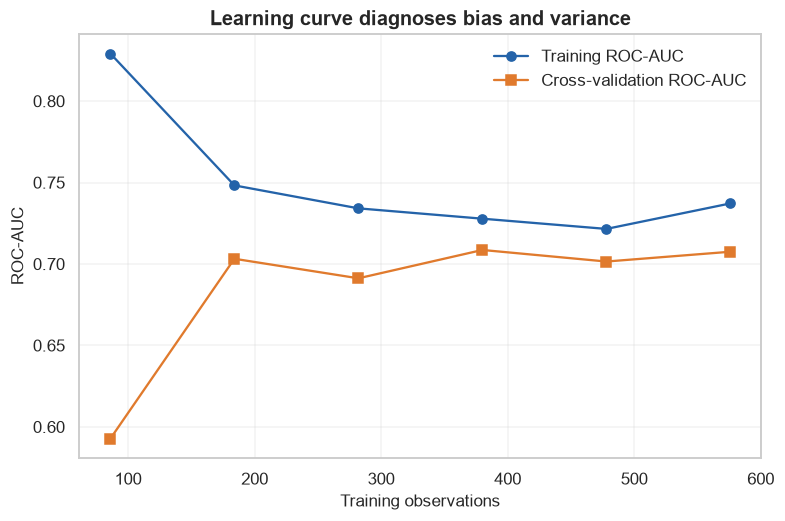

In [4]:
train_sizes,train_scores,validation_scores=learning_curve(model,X_development,y_development,cv=cv,scoring="roc_auc",train_sizes=np.linspace(.15,1,6),n_jobs=1)
train_mean=train_scores.mean(1); validation_mean=validation_scores.mean(1)
figure,axis=plt.subplots(); axis.plot(train_sizes,train_mean,marker="o",label="Training ROC-AUC",color=COURSE_COLORS["blue"]); axis.plot(train_sizes,validation_mean,marker="s",label="Cross-validation ROC-AUC",color=COURSE_COLORS["orange"])
axis.set(title="Learning curve diagnoses bias and variance",xlabel="Training observations",ylabel="ROC-AUC"); axis.legend(); plt.show()

## 18. Common mistakes

            - Using ordinary K-fold for imbalanced classes
- Oversampling before splitting
- Tuning on test data
- Comparing metrics with different positive-label definitions

            ## 19. Advantages and disadvantages

            **Advantages**

            - Makes model selection auditable
- Separates ranking, threshold, and calibration questions

            **Disadvantages**

            - One split has sampling noise
- Cross-validation costs more compute
- Offline metrics may omit deployment effects

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)